# USD/CAD — multivariate FRED backtest

The repo's exchange-rate reference: a head-to-head of conventional time-series methods and an LLM-based forecaster on the FRED USD/CAD dataset. We build targets from the daily `DEXCAUS` series and register a leak-safe covariate panel from macro and rate observations already available in the project: Fed funds, 2Y/10Y Treasury levels and the spread, CPI, unemployment, and WTI oil returns, plus the lagged USD/CAD return.

> Given the same macro-and-rate observations, **which method forecasts the next USD/CAD move best — and can an LLM-Process, handed those covariates, keep up with a gradient-boosting baseline?**

This notebook is the USD/CAD analogue of the multivariate comparison: a clean, reproducible numerical-methods bake-off on a real FRED exchange-rate series, with CRPS and directional metrics. The goal is to test whether the available macro and rate information helps forecast Canadian-dollar moves against the U.S. dollar.

**Methods**

| Family | Predictors | Covariates? |
|---|---|---|
| Naive floor | `LastValuePredictor` | — |
| Classical | ETS, Kalman, AutoARIMA | — (univariate) |
| ML regression | Darts LinearRegression, LightGBM | ✅ optional past covariates |
| LLM-Process | `build_usdcad_llmp_sampled_trajectory` | ✅ optional covariate prompt blocks |

**How it is organised.** Specs (`specs/*.yaml`) carry only the experiment design — the window and the single-horizon tasks. The predictors and their hyperparameters live in code, so model choices are tuned in Python rather than in YAML.

**Workflow:** iterate on the 2025 backtest by setting `EXPERIMENT_CONFIG`, then spend the protected 2026 eval on the finalists. `smoke` is the fast default.

================================================================================


## What's actually forecastable at daily resolution?

- **Target = returns, not the price level.** We forecast **close-to-close cumulative log returns** on the FRED `DEXCAUS` series, one horizon at a time: `usdcad_logret_1b` (next session), `usdcad_logret_5b` (forward 1 week), and `usdcad_logret_21b` (forward 1 month). Forecasting `usdcad_logret_Nb` exactly `N` business days ahead resolves to the **forward** cumulative return over the next `N` sessions.
- **Per horizon:** `h=1` → next-day direction and short-horizon FX positioning; `h=5`/`h=21` → weekly and monthly trend decisions.
- **The caveat:** USD/CAD is a macro-sensitive exchange rate, and the return signal is often weak at daily frequency. Far-ahead point forecasts tend toward zero, so the actionable objects are usually **direction, regime shifts, and conditional volatility** rather than a precise level path. That is why the rate-spread, inflation, and commodity covariates matter most at short horizons, especially when macro conditions are changing.

================================================================================


## ⚠️ Cutoff-aware evaluation — why the windows are what they are

This is the methodological heart of the comparison, and it is easy to get wrong.

- **Numerical methods are cutoff-safe by construction.** Naive, ETS, Kalman, AutoARIMA, LinReg, and LightGBM only ever see the series up to the forecast origin (`ForecastContext` enforces it), so they can be backtested on any historical window — including stressed macro regimes.
- **An LLM is not.** Gemini's training cutoff is roughly **January 2025**, so a model can effectively have memorised pre-2025 macro and FX outcomes. Scoring an LLM-Process on a pre-cutoff origin therefore measures *recall*, not forecasting skill, and can silently flatter it in the head-to-head.

The USD/CAD comparison therefore keeps the LLM-inclusive rows **after the cutoff**:

| Window | Spec | Role | LLMP? |
|---|---|---|---|
| **2025** | `usdcad_smoke.yaml` / `usdcad_backtest_2025.yaml` | open iteration & comparison | ✅ post-cutoff |
| **2026** | `usdcad_eval_2026.yaml` | **protected** held-out test (budgeted) | ✅ post-cutoff |
| **2020 COVID** | `usdcad_stress_2020.yaml` | stressed regime check, **numerical only** | ❌ leaked for LLMs |

This discipline is enforced in code: the predictors cell gates the LLM-Process rows on a `POST_CUTOFF` flag, so selecting `EXPERIMENT_CONFIG = "stress_2020"` drops them automatically while the numerical methods remain valid.

================================================================================


---
## 1. Setup

The heavy lifting lives in helper modules alongside this notebook:

- `data.py` builds the `DataService` for the FRED `DEXCAUS` target and the macro/rate covariate panel.
- `predictors/` contains the USD/CAD LLM-Process recipe and the covariate-aware prompt framing.
- `leaderboard.py` turns cached results into the `RESULTS_DF` leaderboard.
- `analysis.py` / `plots.py` provide direction metrics, styled tables, and figures.

We register one data service that includes the three forward-return targets plus the available FRED covariates. Target-only predictors ignore those covariates, while the covariate-aware variants read them as part of the forecast context.

**First run on the 2025/2026 windows?** Warm the FRED cache first: `uv run python scripts/fetch_fred.py` and make sure the repo-root `.env` includes your `FRED_API_KEY`.

================================================================================


In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from dotenv import load_dotenv


warnings.filterwarnings("ignore")


# Resolve the repo root robustly (walk up for the workspace markers) so the
# proxy creds load regardless of the kernel's working directory.
def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / "pyproject.toml").exists() and (cand / "aieng-forecasting").is_dir():
            return cand
    return here


ROOT = _repo_root()
IMPLEMENTATIONS = ROOT / "implementations"
if str(IMPLEMENTATIONS) not in sys.path:
    sys.path.insert(0, str(IMPLEMENTATIONS))
load_dotenv(ROOT / ".env", override=False)  # LLMP rows call the Vector proxy — need PROXY_* set

from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
    MultiTargetEvalSpec,
    cached_multi_backtest,
    describe_spec,
    multi_evaluate,
)
from aieng.forecasting.methods import (
    DartsAutoARIMAPredictor,
    DartsExponentialSmoothingPredictor,
    DartsKalmanForecasterPredictor,
    DartsLightGBMPredictor,
    DartsLinearRegressionPredictor,
    LastValuePredictor,
)
from usdcad_forecasting import DEFAULT_COVARIATE_SERIES_IDS, build_usdcad_multivariate_service
from usdcad_forecasting.leaderboard import build_leaderboard, build_return_compare_frame
from usdcad_forecasting.plots import (
    display_multivariate_backtest_leaderboard,
    plot_return_forecast_vs_actual_multi,
    plot_usdcad_log_return_recent,
)
from usdcad_forecasting.predictors import build_usdcad_llmp_sampled_trajectory


SPECS_DIR = ROOT / "implementations" / "usdcad_forecasting" / "specs"
PREDICTIONS_DIR = ROOT / "data" / "predictions"

# Data environment (not part of any single experiment): how far back to load
# price/covariate history, and whether to re-fetch caches from source.
DATA_HISTORY_START = "2016-01-01"
REFRESH_CACHE = False

svc = build_usdcad_multivariate_service(
    windows=(1, 5, 21),
    include_covariates=True,
    covariate_series_ids=DEFAULT_COVARIATE_SERIES_IDS,
    start=DATA_HISTORY_START,
    refresh=REFRESH_CACHE,
)

# The covariate panel available to the with-covariates predictors below (an
# optional FRED feed may be skipped, so filter to what actually registered).
registered = set(svc.series_ids)
COVARIATES = [c for c in DEFAULT_COVARIATE_SERIES_IDS if c in registered]
print("targets:", sorted(s for s in registered if s.startswith("usdcad_logret_")))
print(f"covariates registered: {len(COVARIATES)} / {len(DEFAULT_COVARIATE_SERIES_IDS)} requested")

targets: ['usdcad_logret_1b', 'usdcad_logret_21b', 'usdcad_logret_5b']
covariates registered: 8 / 8 requested


---
## 2. Configuration

One selector chooses the backtest window; the rest of the notebook adapts automatically. Specs are still the source of truth for the experiment design — the time window and the task set — while predictors remain in code.

For this USD/CAD study, the relevant specs are `usdcad_smoke.yaml`, `usdcad_backtest_2025.yaml`, `usdcad_eval_2026.yaml`, and `usdcad_stress_2020.yaml`.

================================================================================


In [2]:
# ── Experiment configuration ──────────────────────────────────────────────────
# EXPERIMENT_CONFIG chooses which window drives the backtest (Section 5); all
# downstream cells adapt. The protected 2026 eval (Section 7) is fixed.
#
#   "smoke"          short late-2025 window (~6 weekly origins), post-cutoff.
#                    Fast default; LLM-Process predictors ON.
#   "backtest_2025"  weekly origins across all of 2025 (~50), post-cutoff.
#                    The full comparison; LLMP is slow here — trim the roster.
#   "stress_2020"    the COVID crash (daily origins Feb–Apr 2020). NUMERICAL
#                    ONLY — pre-cutoff is leaked for LLMs, so the predictors cell
#                    drops the LLMP rows for this config.

EXPERIMENT_CONFIG = "smoke"

_BACKTEST_SPEC_FILES = {
    "smoke": "usdcad_smoke.yaml",
    "backtest_2025": "usdcad_backtest_2025.yaml",
    "stress_2020": "usdcad_stress_2020.yaml",
}
_EVAL_SPEC_FILE = "usdcad_eval_2026.yaml"

# 2020 is pre-cutoff → keep the LLM-Process out of the comparison (see Section 0).
POST_CUTOFF = EXPERIMENT_CONFIG in {"smoke", "backtest_2025"}

with (SPECS_DIR / _BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]).open() as f:
    backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(f))

print(
    f"Config: {EXPERIMENT_CONFIG!r}  →  {_BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]}  "
    f"(LLMP {'on' if POST_CUTOFF else 'OFF — pre-cutoff'})"
)
print(describe_spec(backtest_spec, data_service=svc))

Config: 'smoke'  →  usdcad_smoke.yaml  (LLMP on)
MultiTargetBacktestSpec (spec_id=usdcad_smoke)
  description: Smoke multivariate demo: weekly origins in late 2025 (post-cutoff), forecasting USD/CAD forward cumulative log returns at 1/5/21 business days.
  start:       2025-10-06 00:00:00
  end:         2025-11-14 00:00:00
  stride:      5
  warmup:      250
  tasks:       3

Task: usdcad_logret_1b
  description: USD/CAD forward cumulative log return, 1 business day ahead (next-session return / direction).
  horizons:    1
  frequency:   B
  payload:     continuous
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: usdcad_logret_1b
    description:    USD/CAD forward cumulative log return over 1 business day(s) (next-session), derived from FRED DEXCAUS.
    source:         FRED (DEXCAUS), derived
    units:          log-return
    frequency:      B

Task: usdcad_logret_5b
  description: USD/CAD forward cumulative log return, 5 business days ahead (forward 1-week 

---
## 3. Target context — observed USD/CAD returns

The most recent realised next-session returns (`h=1` target). Blue = USD/CAD up over the window; red = USD/CAD down. In the DEXCAUS quote convention, a higher value means the Canadian dollar is weaker relative to the U.S. dollar.

This panel is the raw realised target we are trying to forecast: the daily log-return path of the FRED USD/CAD exchange rate, with the same one-business-day lag and forward-window logic used by the model evaluation.

================================================================================


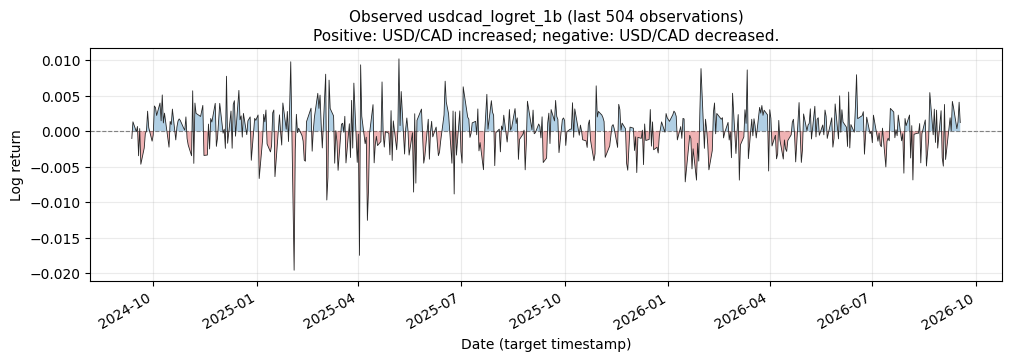

In [3]:
fig, _ = plot_usdcad_log_return_recent(svc, n_trading_days=504)
plt.show()

---
## 4. Predictors — configured in code

This is where you choose the roster. Each predictor implements the same `Predictor` API against the loaded spec; the conventional methods come straight from `aieng.forecasting.methods`, and the LLM-Process variant uses the USD/CAD recipe in `predictors/`. The covariate variants read the registered FRED panel; the target-only variants pass `covariate_series_ids=None`.

| Group | Predictor | Covariates? |
|---|---|---|
| Naive floor | `LastValuePredictor` | — |
| Classical | `DartsExponentialSmoothingPredictor` (ETS), `DartsKalmanForecasterPredictor` | — |
| ML regression | `DartsLinearRegressionPredictor`, `DartsLightGBMPredictor` | target-only **and** + FRED panel |
| LLM-Process | `build_usdcad_llmp_sampled_trajectory` | target-only **and** + panel (post-cutoff only) |

`AutoARIMA` is left commented for speed; add it back when you want a broader classical sweep. The `LLMP (target)` vs `LLMP + cov` comparison is the centerpiece: it measures whether the same macro/rate observations that help the ML models improve the LLM prompt enough to beat the target-only baseline.

================================================================================


In [4]:
# Shared hyperparameters for the Darts regression models.
LAGS = 5  # autoregressive lags (and past-covariate lags) for the regression models
NUM_SAMPLES = 100  # empirical-quantile sample count for the probabilistic Darts models
LGBM_KWARGS = {"num_threads": 1, "n_jobs": 1, "verbosity": -1}

# ── Naive floor + classical (univariate) ──────────────────────────────────────
naive = LastValuePredictor()
ets = DartsExponentialSmoothingPredictor(num_samples=NUM_SAMPLES)
kalman = DartsKalmanForecasterPredictor(num_samples=NUM_SAMPLES)
autoarima = DartsAutoARIMAPredictor(num_samples=NUM_SAMPLES)  # accurate but the slowest classical method

# ── ML regression — target-only vs the covariate panel ────────────────────────
linreg = DartsLinearRegressionPredictor(lags=LAGS, covariate_series_ids=None, num_samples=NUM_SAMPLES)
linreg_cov = DartsLinearRegressionPredictor(
    lags=LAGS, lags_past_covariates=LAGS, covariate_series_ids=COVARIATES, num_samples=NUM_SAMPLES
)
lightgbm = DartsLightGBMPredictor(
    lags=LAGS, covariate_series_ids=None, num_samples=NUM_SAMPLES, lgbm_kwargs=LGBM_KWARGS
)
lightgbm_cov = DartsLightGBMPredictor(
    lags=LAGS,
    lags_past_covariates=LAGS,
    covariate_series_ids=COVARIATES,
    num_samples=NUM_SAMPLES,
    lgbm_kwargs=LGBM_KWARGS,
)

all_predictors = [naive, ets, kalman, autoarima, linreg, linreg_cov, lightgbm, lightgbm_cov]

# Which covariate panel each predictor consumes — drives the leaderboard's
# covariate columns. Predictors absent from this map are treated as target-only.
PREDICTOR_COVARIATES = {
    linreg_cov.predictor_id: COVARIATES,
    lightgbm_cov.predictor_id: COVARIATES,
}
# Short labels for the leaderboard "model" column and the CRPS charts.
PREDICTOR_LABELS = {
    naive.predictor_id: "Naive",
    ets.predictor_id: "ETS",
    kalman.predictor_id: "Kalman",
    autoarima.predictor_id: "AutoARIMA",
    linreg.predictor_id: "LinReg",
    linreg_cov.predictor_id: "LinReg + cov",
    lightgbm.predictor_id: "LightGBM",
    lightgbm_cov.predictor_id: "LightGBM + cov",
}

# ── LLM-Process (sampled trajectories) — target-only vs with-covariates ────────
# Gated on POST_CUTOFF: the 2020 stress window is pre-cutoff and leaked for LLMs,
# so we keep the LLMP rows out of that comparison entirely. The recipe (prompt
# framing, defaults) lives in predictors/llmp_sampled_trajectory.py; tune it
# there, or override model= / n_samples= / history_window= per call here.
if POST_CUTOFF:
    llmp = build_usdcad_llmp_sampled_trajectory(n_samples=8, history_window=48)
    llmp_cov = build_usdcad_llmp_sampled_trajectory(n_samples=8, history_window=48, covariate_series_ids=COVARIATES)
    all_predictors += [llmp, llmp_cov]
    PREDICTOR_COVARIATES[llmp_cov.predictor_id] = COVARIATES
    PREDICTOR_LABELS[llmp.predictor_id] = "LLMP (target)"
    PREDICTOR_LABELS[llmp_cov.predictor_id] = "LLMP + cov"

print(f"{len(all_predictors)} predictors configured (LLMP {'on' if POST_CUTOFF else 'off'}):")
for p in all_predictors:
    print(f"  {p.predictor_id}")

10 predictors configured (LLMP on):
  last_value_naive
  darts_ets
  darts_kalman
  darts_autoarima
  darts_linreg
  darts_linreg_cov
  darts_lightgbm
  darts_lightgbm_cov
  llmp_sampled_trajectories_usdcad_v1_target_h48_n8[gemini-3.1-flash-lite-preview]
  llmp_sampled_trajectories_usdcad_v1_cov_h48_n8[gemini-3.1-flash-lite-preview]


---
## 5. 2025 backtest — the comparison (post-cutoff)

`cached_multi_backtest` runs each predictor across the three forward-return tasks and writes the results to `data/predictions/<spec_id>/`. The loop prints each task’s mean CRPS as it lands. This is the main USD/CAD comparison window where we can examine whether rate, inflation, and commodity signals give the models an edge over the return-only baseline.

================================================================================


In [5]:
results_by_predictor: dict[str, dict[str, object]] = {}

for predictor in all_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results_by_predictor[predictor.predictor_id] = cached_multi_backtest(
        predictor=predictor,
        spec=backtest_spec,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )
    for task_id, result in results_by_predictor[predictor.predictor_id].items():
        print(f"  {task_id:18s}  mean CRPS = {result.mean_score:.5f}  ({len(result.predictions)} preds)")

RESULTS_DF = build_leaderboard(
    results_by_predictor,
    svc,
    covariates_by_predictor=PREDICTOR_COVARIATES,
    labels_by_predictor=PREDICTOR_LABELS,
)

Running last_value_naive ...
  usdcad_logret_1b    mean CRPS = 0.00158  (5 preds)
  usdcad_logret_5b    mean CRPS = 0.00506  (5 preds)
  usdcad_logret_21b   mean CRPS = 0.02451  (5 preds)
Running darts_ets ...
  usdcad_logret_1b    mean CRPS = 0.00143  (5 preds)
  usdcad_logret_5b    mean CRPS = 0.00457  (5 preds)
  usdcad_logret_21b   mean CRPS = 0.01483  (5 preds)
Running darts_kalman ...
  usdcad_logret_1b    mean CRPS = 0.00146  (5 preds)
  usdcad_logret_5b    mean CRPS = 0.00265  (5 preds)
  usdcad_logret_21b   mean CRPS = 0.01561  (5 preds)
Running darts_autoarima ...
  usdcad_logret_1b    mean CRPS = 0.00142  (5 preds)
  usdcad_logret_5b    mean CRPS = 0.00324  (5 preds)
  usdcad_logret_21b   mean CRPS = 0.01112  (5 preds)
Running darts_linreg ...
  usdcad_logret_1b    mean CRPS = 0.00136  (5 preds)
  usdcad_logret_5b    mean CRPS = 0.00295  (5 preds)
  usdcad_logret_21b   mean CRPS = 0.01065  (5 preds)
Running darts_linreg_cov ...
  usdcad_logret_1b    mean CRPS = 0.00139  (5 p

### Leaderboard — mean CRPS by method and horizon

Read it as a story: the signal is weakest for the next-day return and becomes more informative only as the macro structure becomes visible across the run. The spread between methods is usually most pronounced at `h=1` and compresses at longer horizons, while the `dir_*` columns show whether a model is adding directional skill beyond the no-signal baseline.

For this dataset, the most relevant comparisons are usually: target-only baselines vs covariate-aware ML models, and LLMP target-only vs LLMP + FRED covariates.


,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval
0,1,usdcad_logret_1b,LightGBM + cov,True,8,"usdcad_log_ret_1b_l1b, fed_funds_level_l1b, ust2y_level_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b",darts_lightgbm_cov,0.00125,5,5,1,0.400,1.000,0.571,0.400,0.333,5
1,1,usdcad_logret_1b,LinReg,False,0,—,darts_linreg,0.00136,5,5,1,0.500,0.500,0.500,0.600,0.500,5
2,1,usdcad_logret_1b,LightGBM,False,0,—,darts_lightgbm,0.00138,5,5,1,0.333,0.500,0.400,0.400,0.333,5
3,1,usdcad_logret_1b,LinReg + cov,True,8,"usdcad_log_ret_1b_l1b, fed_funds_level_l1b, ust2y_level_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b",darts_linreg_cov,0.00139,5,5,1,0.500,0.500,0.500,0.600,0.500,5
4,1,usdcad_logret_1b,AutoARIMA,False,0,—,darts_autoarima,0.00142,5,5,1,1.000,0.500,0.667,0.800,1.000,5
5,1,usdcad_logret_1b,ETS,False,0,—,darts_ets,0.00143,5,5,1,0.500,0.500,0.500,0.600,0.500,5
6,1,usdcad_logret_1b,Kalman,False,0,—,darts_kalman,0.00146,5,5,1,0.333,0.500,0.400,0.400,0.667,5
7,1,usdcad_logret_1b,Naive,False,0,—,last_value_naive,0.00158,5,5,1,0.500,0.500,0.500,0.600,0.583,5
8,1,usdcad_logret_1b,LLMP (target),False,0,—,llmp_sampled_trajectories_usdcad_v1_target_h48_n8[gemini-3.1-flash-lite-preview],0.00164,5,5,1,0.000,0.000,0.000,0.600,0.500,5
9,1,usdcad_logret_1b,LLMP + cov,True,8,"usdcad_log_ret_1b_l1b, fed_funds_level_l1b, ust2y_level_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b",llmp_sampled_trajectories_usdcad_v1_cov_h48_n8[gemini-3.1-flash-lite-preview],0.00165,5,5,1,0.000,0.000,0.000,0.400,0.333,5


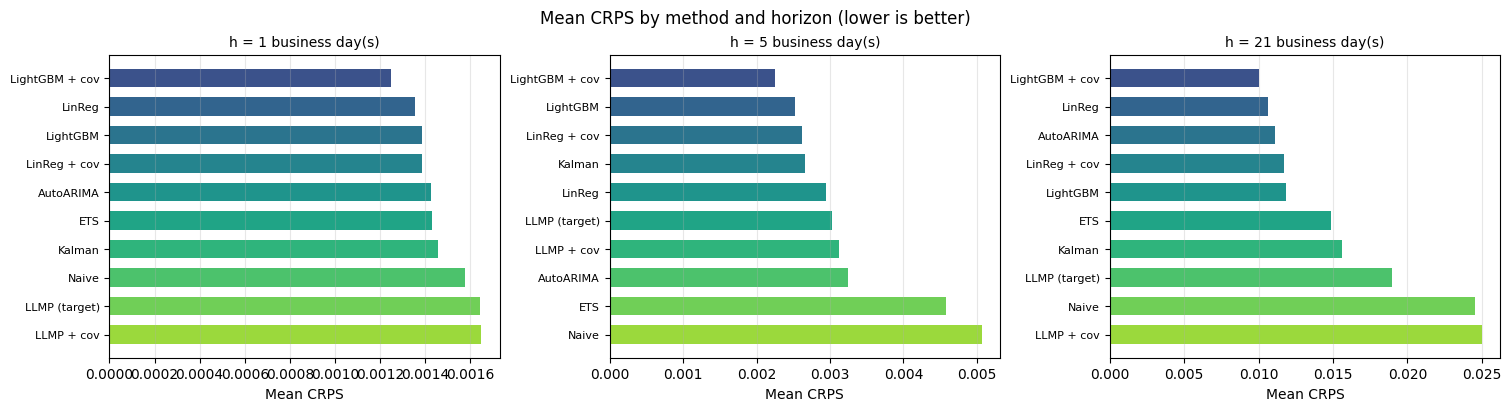

In [6]:
display_multivariate_backtest_leaderboard(RESULTS_DF)

### Reading the LLMP ± covariates rows

When the LLM-Process rows are present (post-cutoff windows), compare them directly:
- **LLMP (target)** — the model sees only the USD/CAD return history.
- **LLMP + cov** — it additionally sees labeled macro/rate blocks from the FRED panel (Fed funds, 2Y/10Y curves, CPI, unemployment, WTI, and lagged USD/CAD return).

Their CRPS gap answers the central question for this dataset: does the exchange-rate model benefit from the same FRED covariates that the ML methods use, or is the signal mostly a short-memory return process? Because these windows are post-cutoff, the LLM is not simply recalling known USD/CAD outcomes.


---
## 6. Forecast vs realised (next session, h=1)

A few models’ median next-session forecast against the realised USD/CAD return (percent). The near-zero, low-amplitude forecasts versus the noisy realised series are the daily FX story made visual: the target is noisy and the macro covariates may help only when the regime is changing. These plots re-use the cached `h=1` predictions from Section 5 rather than re-running the backtest.

================================================================================


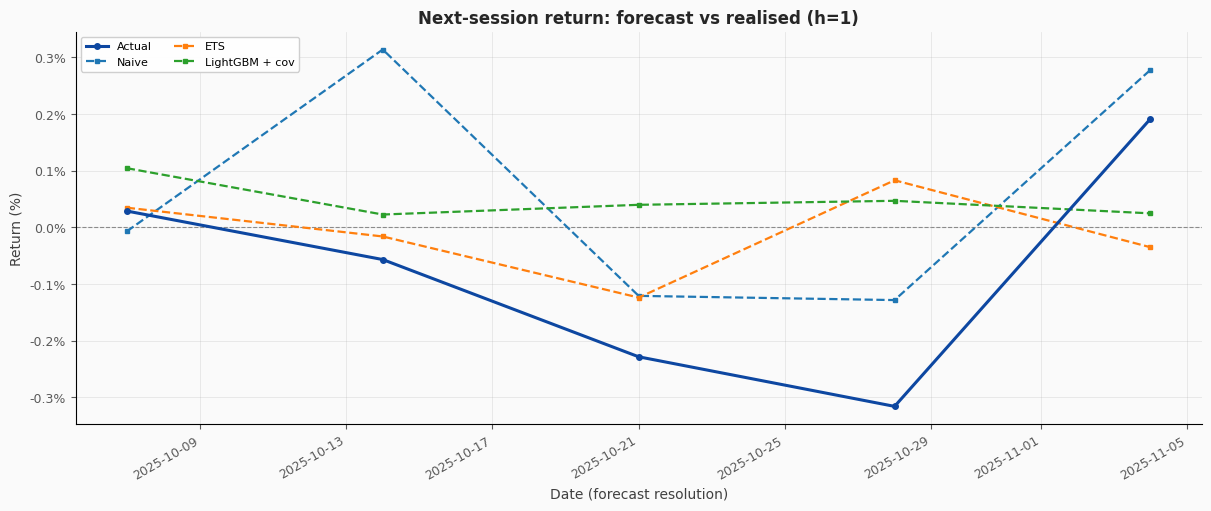

In [7]:
# A few representative models, pulled straight from the cached backtest results.
H1_TASK = "usdcad_logret_1b"
demo_ids = [naive.predictor_id, ets.predictor_id, lightgbm_cov.predictor_id]

compare_by_run: dict[str, pd.DataFrame] = {}
for pid in demo_ids:
    result = results_by_predictor.get(pid, {}).get(H1_TASK)
    if result is None:
        continue
    label = PREDICTOR_LABELS.get(pid, pid)
    compare_by_run[label] = build_return_compare_frame(result.predictions, svc, H1_TASK)

fig, _ = plot_return_forecast_vs_actual_multi(compare_by_run, title="Next-session return: forecast vs realised (h=1)")
plt.show()

---
## 7. Protected 2026 eval — the honest scoreboard

`multi_evaluate()` against the held-out 2026 window. This is a scarce budget: `usdcad_eval_2026.yaml` carries `max_runs`, and one `multi_evaluate` call across the three horizons counts as a single run. Pass an `EvalTracker` to enforce the budget across sessions or leave it off to inspect the raw run numbers.

Spend it on the models you committed to from the 2025 backtest — the finalists list should be small, and it should reflect the real FRED covariate story rather than a broad exploratory sweep. Eval results are never cached, so each run recomputes against the same held-out USD/CAD data.

> **Runtime:** the baseline finalists are the cutoff-safe methods plus the covariate-aware models that showed the strongest 2025 results. Add LLM rows only when you are ready to allocate the protected budget to that comparison.

================================================================================


In [8]:
# from aieng.forecasting.evaluation import EvalTracker
# tracker = EvalTracker(ROOT / "data" / "sp500_eval_runs.yaml")  # enforces max_runs across sessions

with (SPECS_DIR / _EVAL_SPEC_FILE).open() as f:
    eval_spec = MultiTargetEvalSpec.model_validate(yaml.safe_load(f))

# Finalists only — the held-out window is scarce. Pick the handful you committed
# to from the 2025 backtest (e.g. add `llmp`, `llmp_cov` here when ready to spend
# the proxy tokens — they exist only when POST_CUTOFF).
eval_finalists = [naive, lightgbm_cov]

eval_results: dict[str, dict[str, object]] = {}
for predictor in eval_finalists:
    print(f"Evaluating {predictor.predictor_id} ...", flush=True)
    eval_results[predictor.predictor_id] = multi_evaluate(
        predictor=predictor,
        spec=eval_spec,
        data_service=svc,
        tracker=None,  # set to `tracker` above to enforce the max_runs budget
    )
    for task_id, result in eval_results[predictor.predictor_id].items():
        print(f"  {task_id:18s}  mean CRPS = {result.mean_score:.5f}  (run #{result.run_number})")

EVAL_DF = build_leaderboard(
    eval_results,
    svc,
    covariates_by_predictor=PREDICTOR_COVARIATES,
    labels_by_predictor=PREDICTOR_LABELS,
)

Evaluating last_value_naive ...
  usdcad_logret_1b    mean CRPS = 0.00426  (run #1)
  usdcad_logret_5b    mean CRPS = 0.00784  (run #1)
  usdcad_logret_21b   mean CRPS = 0.01932  (run #1)
Evaluating darts_lightgbm_cov ...
  usdcad_logret_1b    mean CRPS = 0.00127  (run #1)
  usdcad_logret_5b    mean CRPS = 0.00484  (run #1)
  usdcad_logret_21b   mean CRPS = 0.00706  (run #1)


,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval,run_number
0,1,usdcad_logret_1b,LightGBM + cov,True,8,"usdcad_log_ret_1b_l1b, fed_funds_level_l1b, ust2y_level_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b",darts_lightgbm_cov,0.00127,8,8,0,0.600,0.600,0.600,0.500,0.533,8,1
1,1,usdcad_logret_1b,Naive,False,0,—,last_value_naive,0.00426,8,8,0,0.667,0.400,0.500,0.500,0.533,8,1
2,5,usdcad_logret_5b,LightGBM + cov,True,8,"usdcad_log_ret_1b_l1b, fed_funds_level_l1b, ust2y_level_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b",darts_lightgbm_cov,0.00484,7,7,1,0.667,0.400,0.500,0.429,0.500,7,1
3,5,usdcad_logret_5b,Naive,False,0,—,last_value_naive,0.00784,7,7,1,0.600,0.600,0.600,0.429,0.300,7,1
4,21,usdcad_logret_21b,LightGBM + cov,True,8,"usdcad_log_ret_1b_l1b, fed_funds_level_l1b, ust2y_level_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b",darts_lightgbm_cov,0.00706,8,8,0,0.667,0.500,0.571,0.625,0.875,8,1
5,21,usdcad_logret_21b,Naive,False,0,—,last_value_naive,0.01932,8,8,0,0.333,0.250,0.286,0.375,0.375,8,1


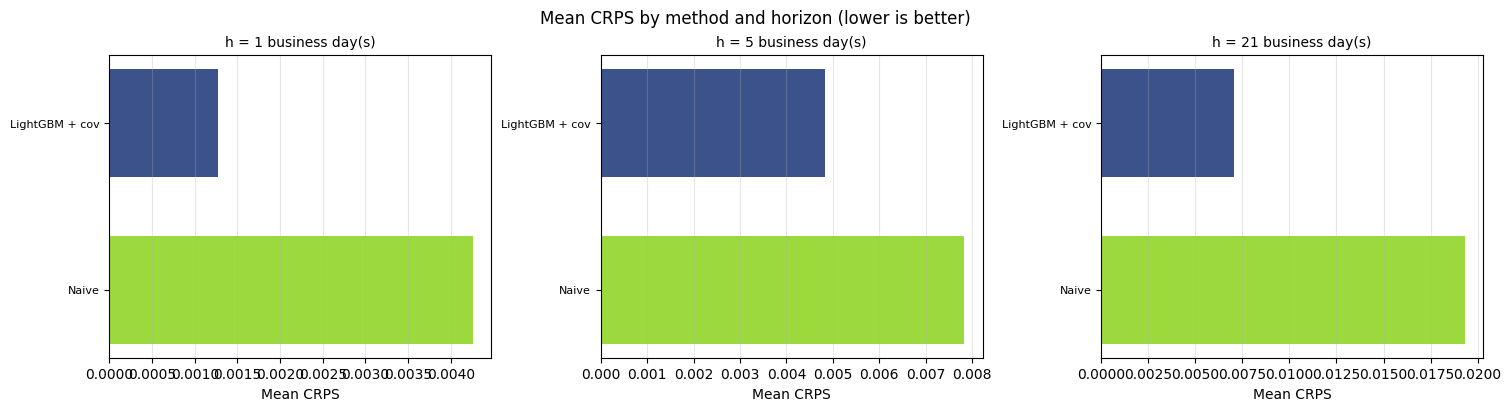

In [9]:
display_multivariate_backtest_leaderboard(EVAL_DF)

---
## Where to go next

- **Scale up the FRED backtest.** Set `EXPERIMENT_CONFIG = "backtest_2025"` for the full weekly-origins run across 2025, with the same USD/CAD target and covariate panel.
- **Study the COVID regime.** Set `EXPERIMENT_CONFIG = "stress_2020"` to isolate a volatile macro episode where a macro-led covariate edge is often most visible. The predictors cell drops the LLM rows automatically for this pre-cutoff window.
- **Add a method.** Instantiate any `Predictor` and append it to `all_predictors`, then add the matching leaderboard label. For a new Darts model, mirror the conventional numerical implementations used in `aieng.forecasting.methods`.
- **Tune the LLM-Process.** Edit the USD/CAD prompt recipe in `predictors/llmp_sampled_trajectory.py` or change `n_samples` / `history_window` in the predictors cell to see how the prompt framing responds to rate and inflation signals.
- **Spend the eval honestly.** Use the protected 2026 window only for the finalists you already believe are strongest from the 2025 FRED comparison.

================================================================================
